In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

plt.style.use("ggplot")
%matplotlib inline

In [2]:
nav = pd.read_csv("../data/processed/clean_nav.csv")
performance = pd.read_csv("../data/processed/clean_performance.csv")
benchmark = pd.read_csv("../data/processed/clean_benchmark.csv")
fund = pd.read_csv("../data/processed/clean_fund_master.csv")

In [3]:
print("NAV:", nav.shape)
print("Performance:", performance.shape)
print("Benchmark:", benchmark.shape)
print("Fund:", fund.shape)


NAV: (46000, 3)
Performance: (40, 19)
Benchmark: (8050, 3)
Fund: (40, 15)


In [4]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [5]:
cagr = performance[[
    "amfi_code",
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct"
]].copy()

cagr.columns = ["AMFI Code", "1 Year CAGR", "3 Year CAGR", "5 Year CAGR"]

cagr.head()

,AMFI Code,1 Year CAGR,3 Year CAGR,5 Year CAGR
0,119551,12.42,12.36,14.45
1,119552,15.25,11.30,14.23
2,119598,24.56,23.39,20.67
3,119599,20.59,23.14,21.82
4,119120,5.34,6.07,5.43


In [6]:
risk_free_rate = 0.065

sharpe = (
    nav.groupby("amfi_code")["daily_return"]
    .agg(["mean", "std"])
    .reset_index()
)

sharpe["Sharpe Ratio"] = (
    (sharpe["mean"] * 252 - risk_free_rate)
    / (sharpe["std"] * np.sqrt(252))
)

sharpe = sharpe[["amfi_code", "Sharpe Ratio"]]

sharpe.head()

,amfi_code,Sharpe Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [7]:
sortino = []

for code, group in nav.groupby("amfi_code"):
    returns = group["daily_return"].dropna()

    downside = returns[returns < 0]

    if len(downside) > 1:
        downside_std = downside.std()

        sortino_ratio = (
            (returns.mean() * 252 - 0.065)
            / (downside_std * np.sqrt(252))
        )
    else:
        sortino_ratio = np.nan

    sortino.append([code, sortino_ratio])

sortino = pd.DataFrame(sortino, columns=["amfi_code", "Sortino Ratio"])

sortino.head()

,amfi_code,Sortino Ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [10]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = benchmark["close_value"].pct_change()

benchmark.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
5750,2022-01-03,CRISIL_LIQUID,2281.51,-0.869574
2300,2022-01-03,NIFTY_MIDCAP150,9721.79,3.261121
6900,2022-01-03,CRISIL_GILT,1451.06,-0.850741
1150,2022-01-03,NIFTY100,17778.24,11.251899


In [11]:
alpha_beta = []

for code in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == code].dropna(subset=["daily_return"])

    merged = pd.merge(
        fund_data[["date", "daily_return"]],
        benchmark[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    if len(merged) > 10:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta.append([code, alpha, beta])

alpha_beta = pd.DataFrame(
    alpha_beta,
    columns=["amfi_code", "Alpha", "Beta"]
)

alpha_beta.head()

,amfi_code,Alpha,Beta
0,100016,0.037661,-0.000003
1,100025,0.044818,-0.000003
2,100033,0.265138,0.000012
3,101206,0.208464,0.000011
4,101207,0.109861,-0.000005


In [12]:
drawdown = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    running_max = group["nav"].cummax()

    dd = (group["nav"] - running_max) / running_max

    drawdown.append([code, dd.min()])

drawdown = pd.DataFrame(
    drawdown,
    columns=["amfi_code", "Maximum Drawdown"]
)

drawdown.head()

,amfi_code,Maximum Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [14]:
print(cagr.columns)
print(sharpe.columns)
print(alpha_beta.columns)
print(drawdown.columns)

Index(['AMFI Code', '1 Year CAGR', '3 Year CAGR', '5 Year CAGR'], dtype='str')
Index(['amfi_code', 'Sharpe Ratio'], dtype='str')
Index(['amfi_code', 'Alpha', 'Beta'], dtype='str')
Index(['amfi_code', 'Maximum Drawdown'], dtype='str')


In [15]:
cagr = cagr.rename(columns={"AMFI Code": "amfi_code"})

In [16]:
scorecard = (
    cagr.merge(sharpe, on="amfi_code")
        .merge(alpha_beta, on="amfi_code")
        .merge(drawdown, on="amfi_code")
)

scorecard["3Y Rank"] = scorecard["3 Year CAGR"].rank(ascending=False)
scorecard["Sharpe Rank"] = scorecard["Sharpe Ratio"].rank(ascending=False)
scorecard["Alpha Rank"] = scorecard["Alpha"].rank(ascending=False)
scorecard["DD Rank"] = scorecard["Maximum Drawdown"].rank(ascending=True)

scorecard["Fund Score"] = (
    0.30 * scorecard["3Y Rank"] +
    0.25 * scorecard["Sharpe Rank"] +
    0.20 * scorecard["Alpha Rank"] +
    0.25 * scorecard["DD Rank"]
)

scorecard = scorecard.sort_values("Fund Score")

scorecard.head()

,amfi_code,1 Year CAGR,3 Year CAGR,5 Year CAGR,Sharpe Ratio,Alpha,Beta,Maximum Drawdown,3Y Rank,Sharpe Rank,Alpha Rank,DD Rank,Fund Score
2,119598,24.56,23.39,20.67,0.945308,0.295143,0.000013,-0.287060,1.0,14.0,3.0,5.0,5.65
39,149324,20.20,20.08,20.61,0.949796,0.296003,0.000008,-0.311719,6.0,13.0,1.0,4.0,6.25
12,120505,14.02,18.08,17.55,1.180101,0.278249,0.000025,-0.181885,8.0,5.0,5.0,16.0,8.65
38,149323,14.12,17.16,19.00,1.132122,0.260204,0.000010,-0.172481,9.0,6.0,8.0,19.0,10.55
7,100033,15.43,16.58,17.69,1.093699,0.265138,0.000012,-0.162172,10.0,7.0,6.0,21.0,11.20


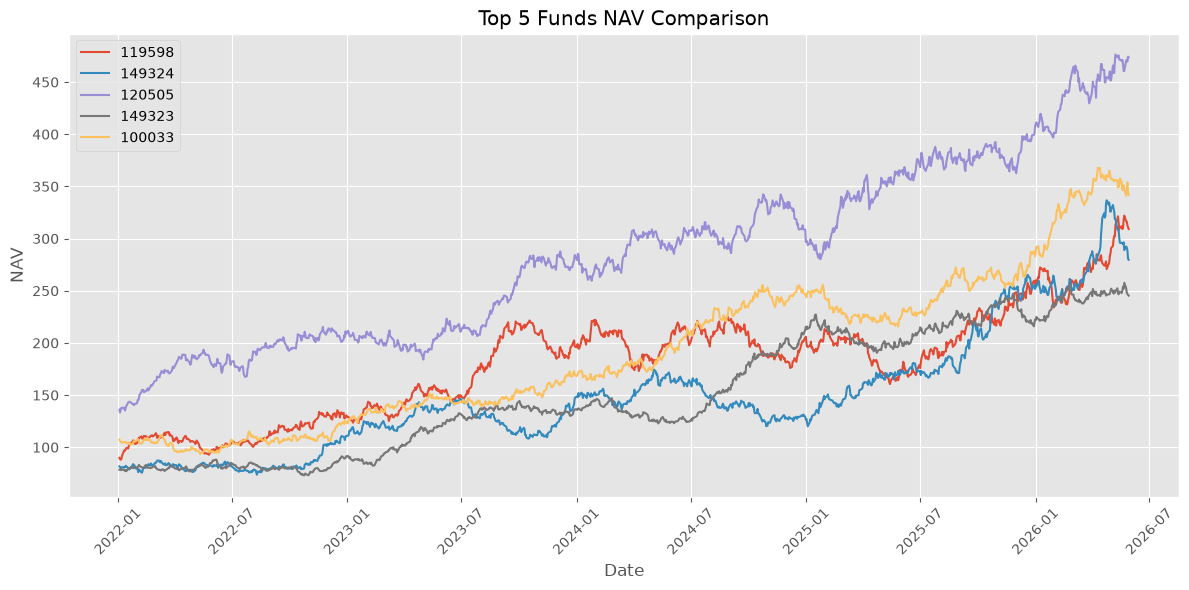

In [17]:
top5 = scorecard.nsmallest(5, "Fund Score")["amfi_code"]

plt.figure(figsize=(12,6))

for code in top5:
    temp = nav[nav["amfi_code"] == code]
    plt.plot(temp["date"], temp["nav"], label=str(code))

plt.title("Top 5 Funds NAV Comparison")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()